In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
df = pd.read_csv("marketing_campaign.csv", sep='\t')

# Check dataframe
print(type(df))

# First 5 rows
print(df.head())

# Remove NA values
df = df.dropna()

# Remove duplicate rows
df = df.drop_duplicates()

# Reset index
df = df.reset_index(drop=True)

# Final shape
print(df.shape)

<class 'pandas.core.frame.DataFrame'>
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  Acc

In [9]:
print(type(df))


<class 'pandas.core.frame.DataFrame'>


In [10]:
print(df.head())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014       94       173  ...                  5             0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0             0

In [11]:
df = df.dropna()

In [12]:
df = df.drop_duplicates()

In [13]:
print(df.shape)

(2216, 29)


In [14]:
#2. Visualize spending patterns and demographics.
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'],dayfirst=True)

In [15]:
df['Age']=2026-df['Year_Birth']

In [16]:
df['Age']

0       69
1       72
2       61
3       42
4       45
        ..
2211    59
2212    80
2213    45
2214    70
2215    72
Name: Age, Length: 2216, dtype: int64

In [17]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts',
                           'MntFishProducts','MntSweetProducts',
                           'MntGoldProds']].sum(axis=1)

In [18]:
df['Total_Spending']

0       1617
1         27
2        776
3         53
4        422
        ... 
2211    1341
2212     444
2213    1241
2214     843
2215     172
Name: Total_Spending, Length: 2216, dtype: int64

In [19]:
df['Family_Size'] = df['Kidhome'] + df['Teenhome'] + 1

In [20]:
df['Family_Size']

0       1
1       3
2       1
3       2
4       2
       ..
2211    2
2212    4
2213    1
2214    2
2215    3
Name: Family_Size, Length: 2216, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

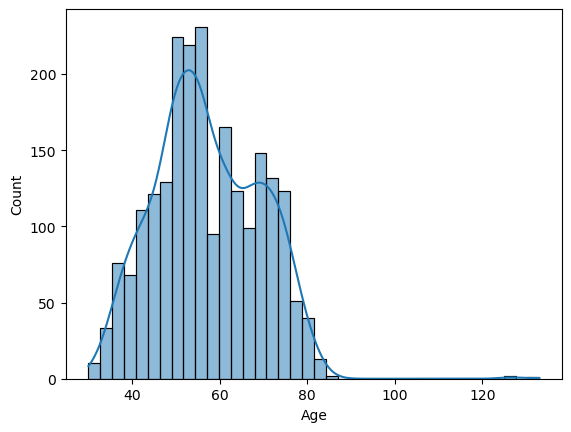

In [21]:
#2. Visualize spending patterns and demographics.
sns.histplot(df['Age'],kde=True)

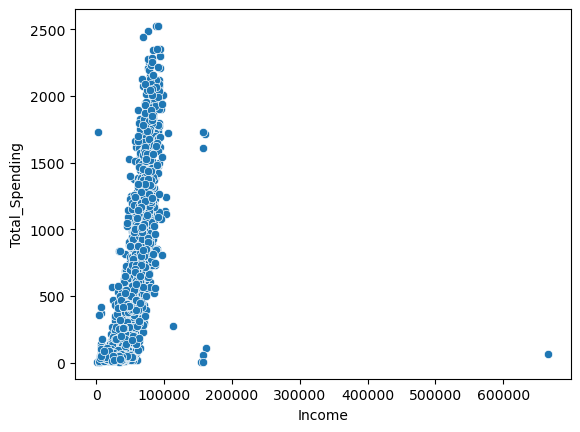

In [22]:
sns.scatterplot(
    data=df,
    x='Income',
    y='Total_Spending'
)

plt.show()

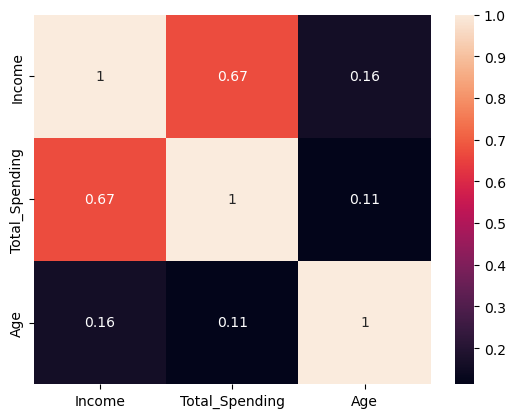

In [23]:
sns.heatmap(df[['Income','Total_Spending','Age']].corr(), annot=True)
plt.show()

In [24]:
# 3. Normalize numerical features (spending, income).